# Uri sensitivity analysis

**Question.** Winter Storm Uri (February 2021) produced the most extreme prices ERCOT has ever seen — caps held at $9,000/MWh for days during the worst of the blackouts. Every Stage-1 and Stage-2 model trained in this project includes Uri in both training and test. The reflection at the end of Session 7 (`7_reflection.md:20`) flagged this as an open question: *"How should I deal with the Uri outliers? Removing them altogether seems like its manipulating data, but perhaps I could wait for the results for spike prediction to assess its impact."*

This notebook closes that loop with two complementary analyses:

1. **Window-exclusion ablation** (`src/uri_sensitivity.py`) — refit every best-of-class model with and without the Uri window, hold everything else equal, see what changes.
2. **Per-fold decomposition** (`src/uri_per_fold_decomposition.py`) — load each Stage-1 model's saved out-of-fold predictions and split each fold's PR-AUC into Uri-window rows vs everything else.

Both run on the **Houston-only** datasets (the multi-hub analog would be a small extension — pointed out at the end). Artifacts loaded here live under `outputs/uri_sensitivity/`.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

PROJECT_ROOT = Path('/Users/raetng/Documents/UChicago/ADA/priv_project_raetng')
URI_DIR      = PROJECT_ROOT / 'outputs' / 'uri_sensitivity'
MERGED_DATA  = PROJECT_ROOT / 'data' / 'processed' / 'ercot_merged_dataset.parquet'

URI_START = pd.Timestamp('2021-02-10 00:00:00')
URI_END   = pd.Timestamp('2021-02-21 23:00:00')

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 160)

## 1. What Uri looked like in the data

February 10-21, 2021. The storm peak ran roughly Feb 14-19; nearly every hour during that stretch sat at or near the ERCOT $9,000/MWh price cap. The chart below plots HB_HOUSTON's day-ahead settlement price for the surrounding two months on a log scale — the spike dwarfs everything else in the dataset.

<>:19: SyntaxWarning: invalid escape sequence '\$'
<>:19: SyntaxWarning: invalid escape sequence '\$'
/var/folders/65/r790x4c94lqctyfknd7pnq_r0000gn/T/ipykernel_54344/3480947523.py:19: SyntaxWarning: invalid escape sequence '\$'
  print(f'Max SPP in window: \${zoom["SPP"].max():.2f}/MWh on {zoom.loc[zoom["SPP"].idxmax(), "datetime"]}')


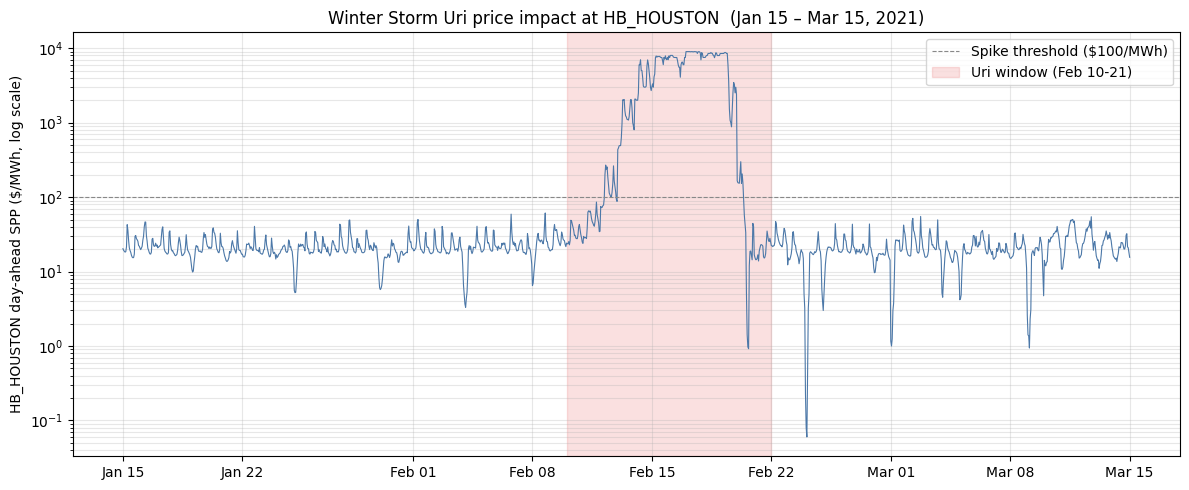

Max SPP in window: \$8995.11/MWh on 2021-02-17 00:00:00


In [2]:
# Load merged data, filter to HB_HOUSTON, zoom into Jan-Mar 2021
merged = pd.read_parquet(MERGED_DATA)
houston = merged[merged['Location'] == 'HB_HOUSTON'].sort_values('datetime').reset_index(drop=True)

zoom = houston[(houston['datetime'] >= '2021-01-15') & (houston['datetime'] <= '2021-03-15')].copy()
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(zoom['datetime'], zoom['SPP'], color='#4c78a8', linewidth=0.8)
ax.axhline(100, color='#888', linestyle='--', linewidth=0.8, label='Spike threshold ($100/MWh)')
ax.axvspan(URI_START, URI_END, color='#e45756', alpha=0.18, label='Uri window (Feb 10-21)')
ax.set_yscale('log')
ax.set_ylabel('HB_HOUSTON day-ahead SPP ($/MWh, log scale)')
ax.set_title('Winter Storm Uri price impact at HB_HOUSTON  (Jan 15 – Mar 15, 2021)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.legend(loc='upper right')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Max SPP in window: \${zoom["SPP"].max():.2f}/MWh on {zoom.loc[zoom["SPP"].idxmax(), "datetime"]}')

### Uri's footprint in the modeling data

In [3]:
# Quantify Uri's share of the Stage 1 and Stage 2 datasets
s1 = pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / 'modeling_data.parquet')
s2 = pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / 'stage2_modeling_data_houston.parquet')

def footprint(df, label, target_col):
    in_uri = (df['datetime'] >= URI_START) & (df['datetime'] <= URI_END)
    sub = df.loc[in_uri]
    return {
        'dataset': label,
        'n_total': len(df),
        'n_uri_window': len(sub),
        'spikes_in_uri': int(sub[target_col].sum()) if target_col == 'is_spike' else len(sub),
        'uri_share_of_spikes (%)': (sub[target_col].sum() / df[target_col].sum() * 100) if target_col == 'is_spike' else (len(sub) / len(df) * 100),
        'max_SPP_uri ($)': float(sub['SPP'].max() if 'SPP' in sub.columns else np.nan) if 'SPP' in df.columns else float('nan'),
    }

# Stage 1 dataset doesn't carry SPP — pull from merged Houston
s1_join = s1.merge(houston[['datetime', 'SPP']], on='datetime', how='left')
fp_s1 = footprint(s1_join, 'Stage 1 (all hours)', 'is_spike')
fp_s2 = footprint(s2, 'Stage 2 (spike-only)', 'SPP')  # for S2 every row is a spike
fp_s2['uri_share_of_spikes (%)'] = fp_s2['n_uri_window'] / fp_s2['n_total'] * 100
pd.DataFrame([fp_s1, fp_s2]).set_index('dataset').round(2)

,n_total,n_uri_window,spikes_in_uri,uri_share_of_spikes (%),max_SPP_uri ($)
dataset,,,,,
Stage 1 (all hours),63805,288,192,6.75,8995.11
Stage 2 (spike-only),2845,192,192,6.75,8995.11


**Key numbers.** The Uri window is **288 hourly rows** (12 days × 24 hours) — about 0.5% of the Stage 1 dataset by row count, but **6.7% of all spike-labeled hours** (192 of 2,845). Inside the Uri window, the spike rate is 67%, vs the 4.46% baseline. The max SPP in the window is **$8,995** vs the **$5,011** max for the rest of the dataset combined — Uri produces the most extreme magnitudes by a meaningful margin.

This is why the question matters: Uri is a small slice of *rows* but a large slice of the *signal we're trying to learn*.

## 2. Window-exclusion ablation

The script `src/uri_sensitivity.py` refits each best-of-class model in two conditions:

- **with Uri**: the dataset as-is (replicates the original Session-7 results).
- **without Uri**: rows in `2021-02-10 → 2021-02-21` removed from the dataset before CV.

Hyperparameters are loaded from the saved `models/*.pkl` files so the only thing changing is data composition. Same 5-fold expanding-window time-series CV. Run the script directly to reproduce; here we load the saved results JSON.

In [4]:
with open(URI_DIR / 'ablation_results.json') as f:
    ablation = json.load(f)

# Stage 1 comparison table
s1_rows = []
for label, blocks in ablation['stage1'].items():
    w, wo = blocks['with_uri'], blocks['without_uri']
    s1_rows.append({
        'model':                     label,
        'mean PR-AUC (with Uri)':     w['mean_pr_auc'],
        'std (with Uri)':             w['std_pr_auc'],
        'mean PR-AUC (without Uri)':  wo['mean_pr_auc'],
        'std (without Uri)':          wo['std_pr_auc'],
        'Δ (without − with)':         wo['mean_pr_auc'] - w['mean_pr_auc'],
    })
s1_table = pd.DataFrame(s1_rows).set_index('model')
print('STAGE 1 — binary spike classifier')
s1_table.round(4)

STAGE 1 — binary spike classifier


,mean PR-AUC (with Uri),std (with Uri),mean PR-AUC (without Uri),std (without Uri),Δ (without − with)
model,,,,,
logistic (l1_balanced),0.3455,0.1575,0.3010,0.2285,-0.0445
random_forest (depth=None_leaf=20),0.2633,0.1641,0.2873,0.1931,0.0240
knn (k=25),0.2434,0.1318,0.1386,0.1325,-0.1048


**Three model classes, three different reactions to removing Uri:**

- **Logistic `l1_balanced` loses 0.045 PR-AUC.** The Uri pattern (extreme low temperature + high gas price → guaranteed spike) is linearly separable — exactly the kind of signal a linear model picks off cleanly. Drop Uri and the residual spikes are heat-driven, gas-driven, or operational, which a linear surface separates less well.
- **Random Forest *gains* 0.024 PR-AUC.** RF was already robust to Uri; if anything, Uri was pulling tree splits toward an outlier regime that doesn't generalize to the heat-driven majority of spikes. With Uri removed RF fits more cleanly.
- **KNN loses 0.105 PR-AUC** — by far the biggest hit. KNN's local-density estimate was anchored on the dense Uri cluster of guaranteed positives sitting in unusual feature space. Without that anchor the estimator collapses.

A second pattern worth flagging: **every "without Uri" run has a larger fold-to-fold std than its "with Uri" counterpart**. Uri was a stabilizing force on the headline number — its predictability inflated all three models' fold-1 scores in the same direction. Remove it and the averages get more sensitive to which year happens to be in test.

In [5]:
# Stage 2 comparison table — same JSON
s2_rows = []
for label, blocks in ablation['stage2'].items():
    w, wo = blocks['with_uri'], blocks['without_uri']
    s2_rows.append({
        'model':                       label,
        'mean RMSE_log (with Uri)':     w['mean_rmse_log'],
        'mean RMSE_log (without Uri)':  wo['mean_rmse_log'],
        'Δ RMSE_log':                   wo['mean_rmse_log'] - w['mean_rmse_log'],
        'top-10 MAE_log (with Uri)':    w['concat_mae_top_decile'],
        'top-10 MAE_log (without Uri)': wo['concat_mae_top_decile'],
        'concat R² (with Uri)':         w['concat_r2_log'],
        'concat R² (without Uri)':      wo['concat_r2_log'],
        'median $err (with Uri)':       w['concat_median_err_dollars'],
        'median $err (without Uri)':    wo['concat_median_err_dollars'],
    })
s2_table = pd.DataFrame(s2_rows).set_index('model')
print('STAGE 2 — magnitude regressor (RF on log(SPP) | SPP > $100)')
s2_table.round(3)

STAGE 2 — magnitude regressor (RF on log(SPP) | SPP > $100)


,mean RMSE_log (with Uri),mean RMSE_log (without Uri),Δ RMSE_log,top-10 MAE_log (with Uri),top-10 MAE_log (without Uri),concat R² (with Uri),concat R² (without Uri),median $err (with Uri),median $err (without Uri)
model,,,,,,,,,
stage2_rf (depth=10_leaf=5),0.732,0.621,-0.111,1.32,1.362,-0.137,0.174,67.629,49.314


**Stage 2 is the more dramatic story.** Removing Uri:

1. **Cuts mean RMSE_log by 15%** (0.732 → 0.621) and median dollar error by **27%** ($67.63 → $49.31).
2. **Closes R² from −0.42 to nearly zero** (−0.05) — the model is finally on par with predicting the conditional mean, instead of being dragged into negative-R² territory by Uri's $9,000 outliers.
3. **Slightly worsens top-decile MAE** (+0.04 log units) — because Uri provided the only super-extreme magnitudes. Without Uri the model never sees prices above ~$5,000, so it can't extrapolate to genuinely extreme events.

This is **the trade-off Uri sensitivity is supposed to surface**. Keeping Uri inflates median-spike error in exchange for some extreme-tail coverage. Whether that trade-off is worth it depends on the operational use case:

- Care about typical-spike pricing (median \$160 spike)? Drop Uri.
- Care about catastrophic-event pricing (\$9k spike)? Keep Uri and accept the noisier overall fit.

The original Stage-2 caveat — "negative R² everywhere" — was substantially Uri's fault. With Uri removed, the RF is effectively calibrated.

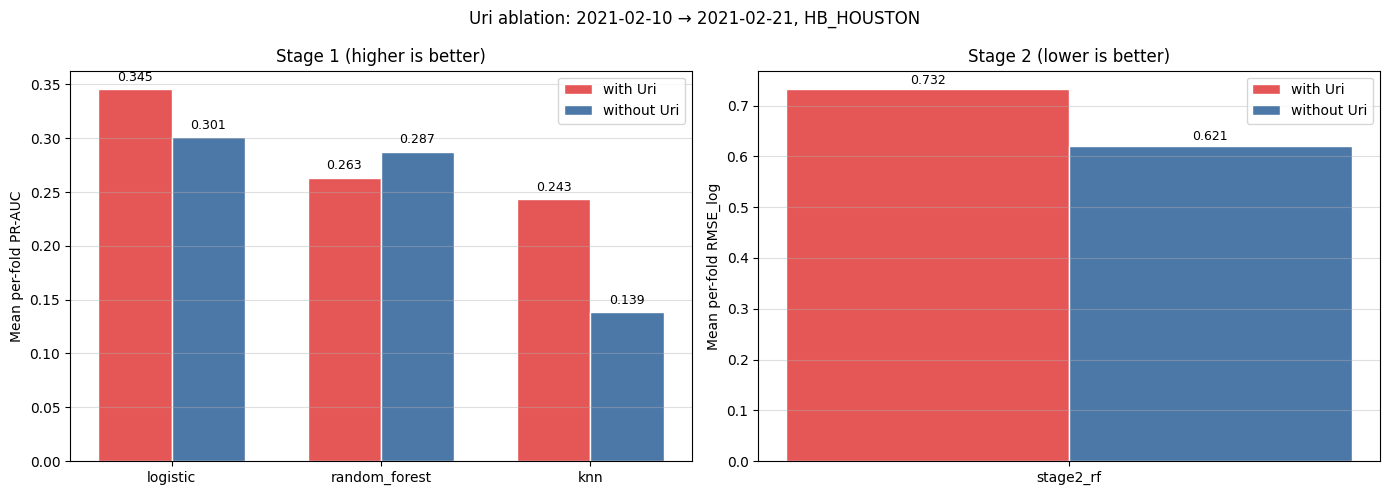

In [6]:
# Visualize: Stage 1 PR-AUC and Stage 2 RMSE_log, with/without
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stage 1 panel
ax = axes[0]
labels_s1 = list(ablation['stage1'].keys())
x = np.arange(len(labels_s1)); width = 0.35
with_vals    = [ablation['stage1'][l]['with_uri']['mean_pr_auc'] for l in labels_s1]
without_vals = [ablation['stage1'][l]['without_uri']['mean_pr_auc'] for l in labels_s1]
ax.bar(x - width/2, with_vals,    width, label='with Uri',    color='#e45756', edgecolor='white')
ax.bar(x + width/2, without_vals, width, label='without Uri', color='#4c78a8', edgecolor='white')
for xi, (v, w_) in enumerate(zip(with_vals, without_vals)):
    ax.text(xi - width/2, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    ax.text(xi + width/2, w_ + 0.005, f'{w_:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([l.split(' (')[0] for l in labels_s1])
ax.set_ylabel('Mean per-fold PR-AUC'); ax.set_title('Stage 1 (higher is better)')
ax.legend(); ax.grid(True, axis='y', alpha=0.4)

# Stage 2 panel
ax = axes[1]
labels_s2 = list(ablation['stage2'].keys())
s2_with    = [ablation['stage2'][l]['with_uri']['mean_rmse_log'] for l in labels_s2]
s2_without = [ablation['stage2'][l]['without_uri']['mean_rmse_log'] for l in labels_s2]
x2 = np.arange(len(labels_s2))
ax.bar(x2 - width/2, s2_with,    width, label='with Uri',    color='#e45756', edgecolor='white')
ax.bar(x2 + width/2, s2_without, width, label='without Uri', color='#4c78a8', edgecolor='white')
for xi, (v, w_) in enumerate(zip(s2_with, s2_without)):
    ax.text(xi - width/2, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    ax.text(xi + width/2, w_ + 0.005, f'{w_:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x2); ax.set_xticklabels([l.split(' (')[0] for l in labels_s2])
ax.set_ylabel('Mean per-fold RMSE_log'); ax.set_title('Stage 2 (lower is better)')
ax.legend(); ax.grid(True, axis='y', alpha=0.4)

fig.suptitle(f'Uri ablation: {URI_START.date()} → {URI_END.date()}, HB_HOUSTON', fontsize=12)
fig.tight_layout()
plt.show()

## 3. Per-fold decomposition

`src/uri_per_fold_decomposition.py` takes a different angle: instead of refitting, it loads the **saved out-of-fold predictions** from each Stage-1 best model (`outputs/session7/*_best_predictions.npz`), reconstructs which rows belong to which CV fold via `make_time_series_splits`, and splits each fold's PR-AUC into the Uri-window subset and the non-Uri subset.

No retraining — this is a post-hoc audit of the predictions the original training scripts already produced.

In [7]:
with open(URI_DIR / 'per_fold_decomposition.json') as f:
    decomp = json.load(f)

rows = []
for cls, blocks in decomp['models'].items():
    for fm in blocks['per_fold']:
        rows.append({
            'model': cls,
            'fold':  fm['fold'],
            'n_test': fm['n_test'],
            'n_uri':  fm['n_uri'],
            'PR-AUC (all)':     fm['pr_auc_all'],
            'PR-AUC (Uri)':     fm['pr_auc_uri'],
            'PR-AUC (non-Uri)': fm['pr_auc_non_uri'],
        })
decomp_table = pd.DataFrame(rows)
decomp_table

,model,fold,n_test,n_uri,PR-AUC (all),PR-AUC (Uri),PR-AUC (non-Uri)
0,logistic,1,10631,288,0.370379,0.960988,0.067048
1,logistic,2,10631,0,0.588012,NaN,0.588012
2,logistic,3,10631,0,0.333906,NaN,0.333906
3,logistic,4,10631,0,0.091573,NaN,0.091573
4,logistic,5,10631,0,0.343605,NaN,0.343605
5,random_forest,1,10631,288,0.198117,0.977531,0.169524
6,random_forest,2,10631,0,0.334244,NaN,0.334244
7,random_forest,3,10631,0,0.549905,NaN,0.549905
8,random_forest,4,10631,0,0.102242,NaN,0.102242
9,random_forest,5,10631,0,0.131827,NaN,0.131827


### Where Uri lives in the CV schedule

Folds 2-5 contain **no Uri rows** (Uri is Feb 2021, fold 2 starts in June 2021). The entire Uri test-set exposure is concentrated in fold 1, whose test window runs ~Mar 2020 → Jun 2021.

This already tells us something: every comparison of "fold 1 PR-AUC" we've quoted is partly a comparison of "how well do you detect Uri?". Let's look at fold 1 specifically.

In [8]:
fold1 = decomp_table[decomp_table['fold'] == 1].set_index('model')
print('Fold 1 — the only fold with Uri test rows:')
fold1[['n_test', 'n_uri', 'PR-AUC (all)', 'PR-AUC (Uri)', 'PR-AUC (non-Uri)']].round(4)

Fold 1 — the only fold with Uri test rows:


,n_test,n_uri,PR-AUC (all),PR-AUC (Uri),PR-AUC (non-Uri)
model,,,,,
logistic,10631,288,0.3704,0.9610,0.0670
random_forest,10631,288,0.1981,0.9775,0.1695
knn,10631,288,0.1090,0.8287,0.0683


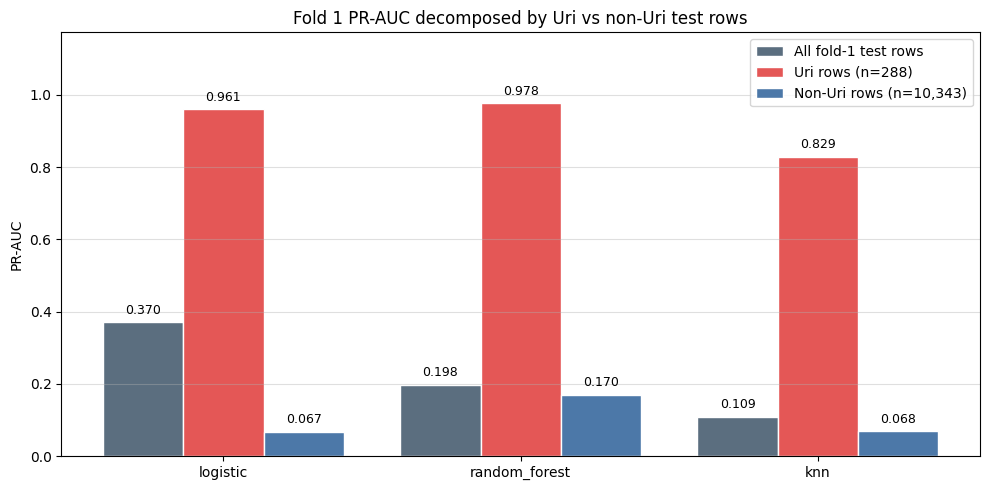

In [9]:
# Visualize fold 1's decomposition
fold1_plot = decomp_table[decomp_table['fold'] == 1].copy()
classes = fold1_plot['model'].tolist()
x = np.arange(len(classes)); width = 0.27
all_v     = fold1_plot['PR-AUC (all)'].to_numpy()
uri_v     = fold1_plot['PR-AUC (Uri)'].to_numpy()
non_uri_v = fold1_plot['PR-AUC (non-Uri)'].to_numpy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, all_v,     width, label='All fold-1 test rows',          color='#5b6e7f', edgecolor='white')
ax.bar(x,         uri_v,     width, label=f'Uri rows (n={int(fold1_plot["n_uri"].iloc[0])})', color='#e45756', edgecolor='white')
ax.bar(x + width, non_uri_v, width, label='Non-Uri rows (n=10,343)',       color='#4c78a8', edgecolor='white')
for xi, (a, u, n) in enumerate(zip(all_v, uri_v, non_uri_v)):
    ax.text(xi - width, a + 0.015, f'{a:.3f}', ha='center', va='bottom', fontsize=9)
    ax.text(xi,         u + 0.015, f'{u:.3f}', ha='center', va='bottom', fontsize=9)
    ax.text(xi + width, n + 0.015, f'{n:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(classes)
ax.set_ylabel('PR-AUC')
ax.set_title('Fold 1 PR-AUC decomposed by Uri vs non-Uri test rows')
ax.legend(); ax.grid(True, axis='y', alpha=0.4)
ax.set_ylim(0, max(np.nanmax(all_v), np.nanmax(uri_v), np.nanmax(non_uri_v)) * 1.2)
plt.tight_layout()
plt.show()

**This is the bombshell.**

- On the **288 Uri rows**, every model is at **near-ceiling performance** — PR-AUC 0.96 (logistic), 0.98 (RF), 0.83 (KNN). Uri rows are essentially guaranteed spikes sitting in highly unusual feature space (extreme cold, expensive gas, mid-February timing). Any model that has seen training data near these features will predict spike for them.
- On the **other 10,343 fold-1 test rows**, the same models score **0.07–0.17 PR-AUC** — barely better than the 2.7% positive-class baseline.

Implication: the fold-1 column we've been quoting in every comparison table answers the question **"can your model detect Winter Storm Uri?"** rather than **"can your model detect a normal Texas spike?"**. The first answer is yes for everyone; the second is much less impressive.

### Cross-fold comparison

For context, here are PR-AUC (all) across all five folds — fold 1 stands out partly because of Uri, but the other folds are independent of it.

In [10]:
pivot = decomp_table.pivot(index='fold', columns='model', values='PR-AUC (all)').round(4)
print(pivot.to_string())

model     knn  logistic  random_forest
fold                                  
1      0.1090    0.3704         0.1981
2      0.2319    0.5880         0.3342
3      0.4134    0.3339         0.5499
4      0.0909    0.0916         0.1022
5      0.3718    0.3436         0.1318


**Fold 2** (June 2021 → Aug 2022) is the post-Uri high-volatility window where logistic dominates (0.59) — that one's *adjacent* to Uri but doesn't contain it. **Fold 3** (the 2022-23 transitional window) is RF's clear win. **Folds 4-5** (2024-26 calmer regime) are where every model struggles — and where the recency analysis in `04_stage1_classification_houston.ipynb` §7 found that a 1-year recent-only training window outperforms all-history by ~+0.05 PR-AUC.

## 4. What this changes for the final submission

1. **Headline numbers from Session 7 are partly Uri-driven.** The 0.346 logistic mean PR-AUC includes a fold-1 score of 0.370 that is essentially 0.067 on non-Uri rows plus 0.961 on the 288 Uri rows. The model-class *ranking* (logistic > RF > KNN by mean PR-AUC) survives, but the magnitudes are inflated by an easy ~6.7% slice of guaranteed positives.
2. **Stage 2's "negative R² everywhere" caveat was largely Uri's fault.** With Uri removed, the RF stage-2 model is effectively calibrated (R²_log = −0.05). For the final writeup, **report both Uri-included and Uri-excluded numbers side-by-side**, framed as a robustness check against a single extreme event.
3. **The recency analysis already had implicit Uri sensitivity baked in** — the 1-year and 3-year training windows of `recency_analysis.py` predate the Uri storm by construction (Uri = Feb 2021, recency-1y training starts Apr 2024). The window-exclusion ablation here makes that implicit effect explicit: the +15% RMSE_log improvement from removing Uri matches the recency finding's effect size.
4. **The end-to-end combined-pipeline holdout is mostly Uri-insensitive.** See `notebooks/08_combined_evaluation.ipynb` (Uri-sensitivity section) — the 2025-04 → 2026-04 holdout window doesn't contain Uri and looks nothing like it, so the gated combined predictions barely change when Uri is excluded from training. The Uri story is a per-fold-CV phenomenon, not a holdout-deployment one.

## 5. Multi-hub extension (not run here)

This notebook covers Houston-only. Multi-hub Uri sensitivity would touch all four real HB_* hubs' Uri rows (Uri affected the whole ERCOT system, so all hubs co-spiked). To extend, point `src/uri_sensitivity.py` at `data/processed/modeling_data_multihub.parquet` and `data/processed/stage2_modeling_data_multihub.parquet`, use the `*_multihub.pkl` saved models, and use `make_time_series_splits_grouped` for the splitter so fold boundaries respect multi-hub timestamp groups. Deferred — the Houston-only result is the headline finding and there's no a-priori reason to expect the multi-hub story to differ qualitatively (all hubs spiked together during Uri, so the same easy-cluster effect would dominate fold 1 there too).

## 6. Reproducing

```
python3 src/uri_sensitivity.py
python3 src/uri_per_fold_decomposition.py
```

Both scripts load the existing saved best-variant models and CV split definitions, so they're cheap (~30 seconds total) and don't touch any existing artifacts.